In [1]:
%load_ext autoreload
%autoreload 2
%env CUPY_ACCELERATORS=cutensor,cub
%env TENSORLY_BACKEND=cupy
import tensorly as tl
import plotly.io as pio
pio.renderers.default = 'iframe'
tl.tenalg.set_backend('einsum')
tl.plugins.use_opt_einsum()
print(f'TensorLy backend: {tl.get_backend()}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUPY_ACCELERATORS=cutensor,cub
env: TENSORLY_BACKEND=cupy
TensorLy backend: cupy


In [2]:
from moabb.datasets import *
from moabb.paradigms import P300

dataset = BNCI2014_009()
paradigm = P300(resample=32)
epochs, labels, meta = paradigm.get_data(dataset, subjects=[1], return_epochs=True)

/usr/local/share/venv/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning:

warnEpochs <Epochs | 576 events (all good), 0 – 0.801 s (baseline off), ~14.5 MiB, data loaded,
 'Target': 96
 'NonTarget': 480>

/usr/local/share/venv/lib64/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning:

This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.

/usr/local/share/venv/lib/python3.12/site-packages/moabb/datasets/preprocessing.py:279: UserWarning:

warnEpochs <Epochs | 576 events (all good), 0 – 0.801 s (baseline off), ~14.5 MiB, data loaded,
 'Target': 96
 'NonTarget': 480>

/usr/local/share/venv/lib64/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning:

This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This 

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/share/venv/lib64/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning:

This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.

/usr/local/share/venv/lib64/python3.12/site-packages/sklearn/pipeline.py:62: FutureWarning:

This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.

/usr/local/share/venv/lib/python3.12/site-packages/moabb/paradigms/base.py:350: RuntimeWarning:

Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.



No projector specified for this dataset. Please consider the method self.add_proj.


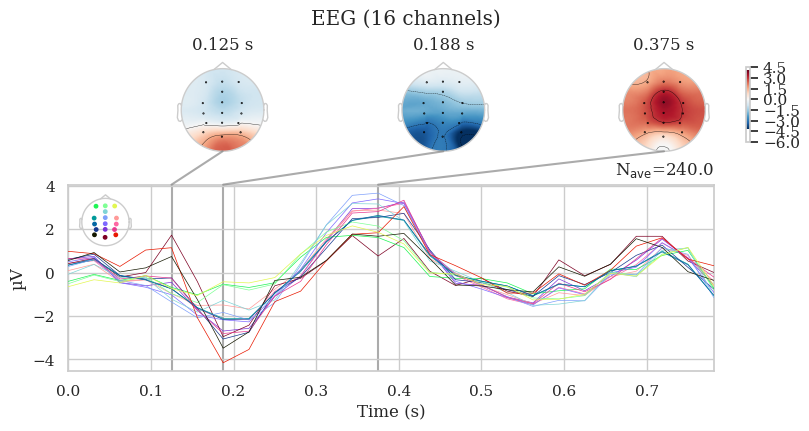

In [3]:
from mne import combine_evoked

contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])
contrast.plot_joint();

In [4]:
from hoda.classification import ZScore
X = tl.tensor(epochs.get_data())
y = labels
X_st = ZScore().fit_transform(X)
X.shape

(1728, 16, 26)

In [5]:
from hoda.hoda import HODA

hoda = HODA(
        rank=[5,5],
        max_iter=128,
        tol=1e-6,
        shrinkage='lw',
        refit_shrinkage=True,
        obj='tr',
        solver='lanczos',
        toeplitz=(1,),
        taper=False,
        extra_train_info=False,
        verbose=False,
        theta=None,
        forward=True       
)


In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from hoda.util import flip_signs
from hoda.cov import mode_scatter, ledoit_wolf_shrinkage
from hoda.util import solve_gevdh

plt.style.use('default')

%load_ext line_profiler
hoda.fit_backward(X_st,y)
df = pd.DataFrame(hoda.train_info_['backward'])

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
[-2.16180347 -2.17024305 -1.22611195 -2.12835282  0.24729333 -0.17535315
 -1.72779855  2.76488809  1.98052889  1.57536332  3.31331694  0.18931568
  3.01805522  1.91207364 -0.88005614 -0.90677744 -2.45511591 -1.93553887
 -1.84297103 -0.87741843 -0.26815018 -0.49912947 -0.01585923  0.58641461
 -0.35325573  0.29947822]
[-2.1618035  -2.170243   -1.2261119  -2.1283529   0.24729332 -0.17535315
 -1.7277986   2.764888    1.9805288   1.5753633   3.3133168   0.18931568
  3.0180552   1.9120736  -0.88005614 -0.90677744 -2.4551158  -1.9355389
 -1.8429711  -0.8774184  -0.26815018 -0.49912947 -0.01585923  0.5864146
 -0.35325575  0.29947823]


In [7]:
import plotly.express as px

px.imshow(tl.to_numpy(hoda.scatter_w_[0]))

In [8]:
px.imshow(tl.to_numpy(hoda.scatter_w_[1]))

In [9]:
df

,iteration,mode,flip,update,shrinkage,objective
0,1,1,1,1.348845e+00,0.000378,373824.579909
1,1,2,2,1.370169e+00,0.028889,91556.362929
2,2,1,3,1.171170e+00,0.001339,158430.080373
3,2,2,4,1.262769e+00,0.029759,85813.170523
4,3,1,5,1.421498e-01,0.001236,53147.713803
5,3,2,6,6.824064e-02,0.029864,86349.807182
6,4,1,7,8.349824e-02,0.001250,20262.360955
7,4,2,8,8.938392e-01,0.030081,86735.833924
8,5,1,9,6.770415e-02,0.001275,10519.359244
9,5,2,10,6.868275e-02,0.029935,86627.730772


In [10]:
import plotly.express as px

if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_tr')
    fig.show()


In [11]:
if hoda.extra_train_info:
    fig = px.line(df, x='flip', y='F_rt')
    fig.show()


In [12]:

px.line(df, x='flip', y='update', log_y=True, color='mode')


In [13]:
px.line(df, x='flip', y='shrinkage', log_y=False, color='mode')

In [14]:
px.line(df, x='flip', y='objective', log_y=True, color='mode')

In [15]:
from hoda.util import ridge_regression

%lprun -f ridge_regression hoda.fit_forward(X,y)
df = pd.DataFrame(hoda.train_info_['forward'])
df

,iteration,mode,flip,update
0,1,1,1,4.458490e+00
1,1,2,2,7.940085e-01
2,2,1,3,1.015227e-01
3,2,2,4,1.215381e-02
4,3,1,5,5.148537e-03
5,3,2,6,9.059176e-04
6,4,1,7,4.699242e-04
7,4,2,8,9.337397e-05
8,5,1,9,5.243764e-05
9,5,2,10,1.073504e-05


Timer unit: 1e-09 s

Total time: 0.0127098 s
File: /home/arne/Workspace/PhD/hoda-bci/src/hoda/util.py
Function: ridge_regression at line 134

Line #      Hits         Time  Per Hit   % Time  Line Contents
   134                                           def ridge_regression(X, Y, lambda_=0):
   135                                               """
   136                                               Compute the ridge regression solution for matrix Y.
   137                                           
   138                                               X: Input matrix (n x p)
   139                                               Y: Target matrix (n x m)
   140                                               lambda_: Regularization parameter
   141                                           
   142                                               Returns:
   143                                               W: The ridge regression weight matrix (p x m)
   144                                    

In [16]:
if hoda.extra_train_info:
    px.line(df, x='flip', y='mse', log_y=True)

In [17]:
px.line(df, x='flip', y='update', log_y=True, color='mode')

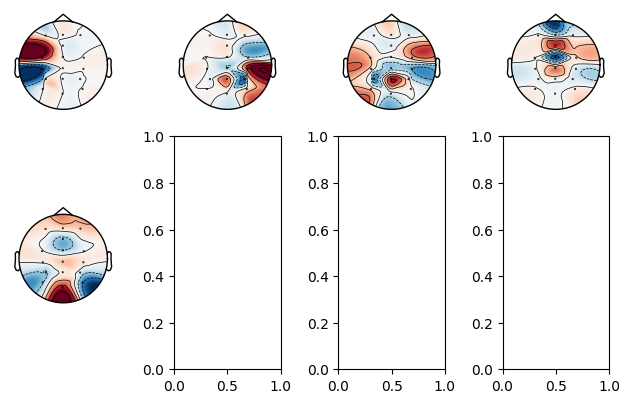

In [18]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
vmax = float(tl.max(tl.abs(hoda.weights_[0])))
for i in range(hoda.rank_[0]):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])

In [19]:
from mne.viz import plot_topomap
from plotly.tools import mpl_to_plotly

# TODO spatial weights
df = pd.DataFrame(tl.to_numpy(hoda.weights_[1]))
df['time'] = epochs.times
df = df.melt(id_vars=['time'], var_name='rank', value_name='weight')
px.line(df, x='time', y='weight', facet_col='rank', facet_col_wrap=4)

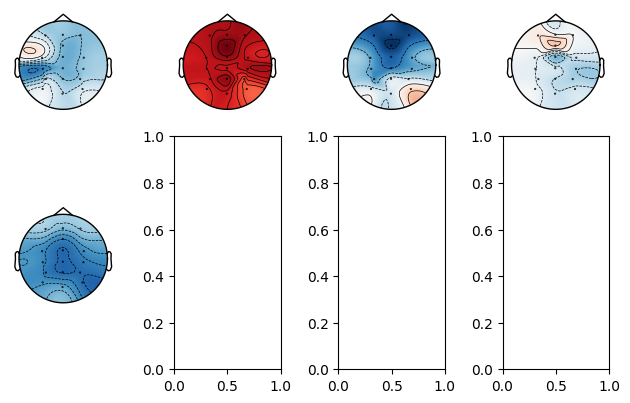

In [20]:

n_row = int(np.ceil(hoda.rank_[0] / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
vmax = float(tl.max(tl.abs(A)))
for i in range(hoda.rank_[0]):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False, vlim=[-vmax, vmax])


In [21]:
df = pd.DataFrame(tl.to_numpy(hoda.aps_[1]))
df['time'] = epochs.times
df = df.melt(id_vars=['time'], var_name='rank', value_name='amplitude')
px.line(df, x='time', y='amplitude', facet_col='rank', facet_col_wrap=4)

In [22]:
from sklearn.feature_selection import SelectFpr, SelectFwe, SelectFdr
import numpy as np
from sklearn.preprocessing import StandardScaler

Xt = hoda.transform(X_st)
xt = tl.to_numpy(tl.unfold(Xt,0))
xt = StandardScaler().fit_transform(xt)

select = SelectFdr(alpha=.05)
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'p_value': select.pvalues_,
    'significant': select.get_support()
})
df

,feature,F,p_value,significant
0,0,0.096723,7.558362e-01,False
1,1,0.066410,7.966680e-01,False
2,2,2.784436,9.536558e-02,False
3,3,4.236842,3.970551e-02,False
4,4,1.576222,2.094757e-01,False
5,5,0.076542,7.820729e-01,False
6,6,0.004483,9.466251e-01,False
7,7,0.882694,3.475964e-01,False
8,8,2.553058,1.102640e-01,False
9,9,1.500149,2.208156e-01,False


In [23]:
fig = px.bar(df, x='feature', y='F', color='significant', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [24]:
X_rec = hoda.inv_transform(Xt)
px.imshow(X_rec[5].get(), color_continuous_scale='RdBu_r', aspect='auto',     zmin=-1.5,
    zmax=1.5,)

In [25]:
from sklearn.manifold import TSNE

x_viz = TSNE(n_components=2).fit_transform(xts)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)

In [26]:
from sklearn.metrics import get_scorer

scorer = get_scorer(paradigm.scoring)
scorer([0,1],[0,1])

TypeError: _BaseScorer.__call__() missing 1 required positional argument: 'y_true'